# Deep Q-Learning Sensor Placement

Harris corner detection places outer sensors first. `SensorDRL` then trains a DQN policy that sequentially places inner sensors.

In [1]:
import importlib
import Analysis.visualization as visualization
from Analysis.visualization import VisualTool
from Engine.map_loader import MapLoader
from Engine.masks import layer_map
from InnerDeployment.DRL.main import SensorDRL
from OuterDeployment.HarrisCorner import HarrisCorner

importlib.reload(visualization)
VisualTool = visualization.VisualTool

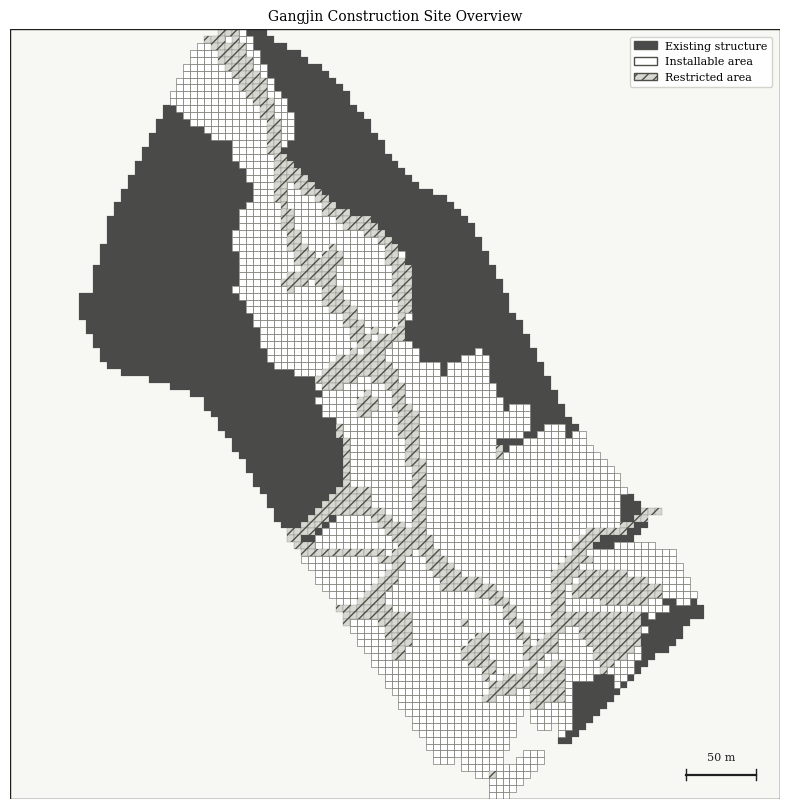

Saved figure: __RESULTS__/_plots/06-19-06-34/construction_map_overview.png


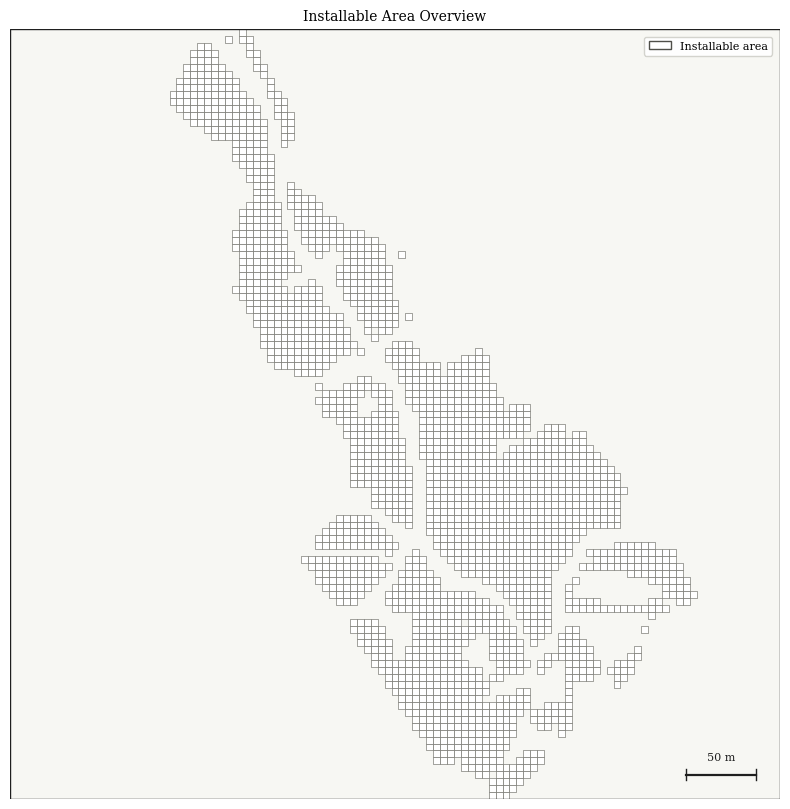

Saved figure: __RESULTS__/_plots/06-19-06-34/installable_map_overview.png


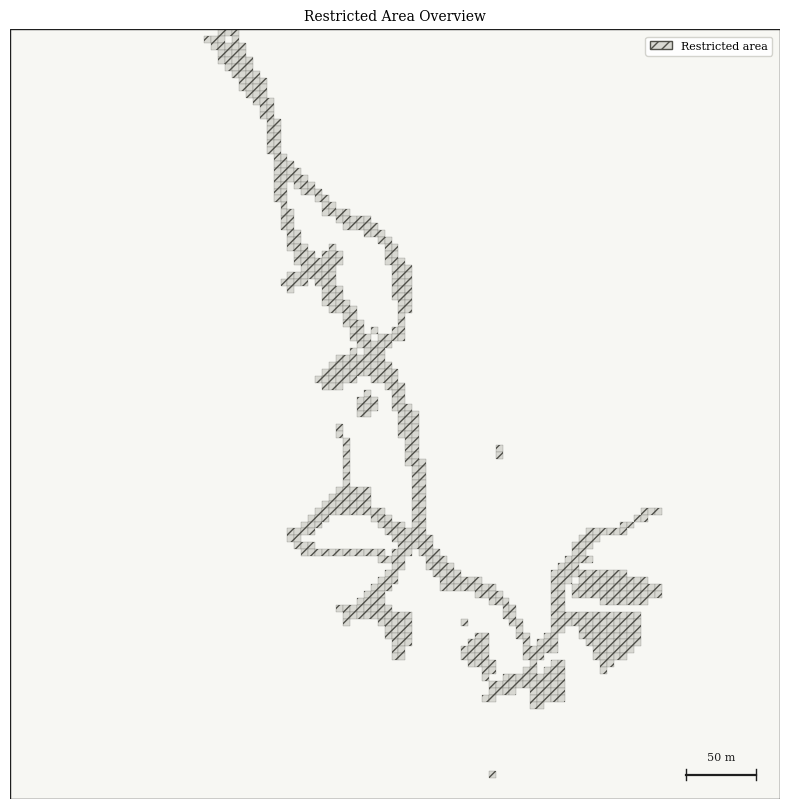

Saved figure: __RESULTS__/_plots/06-19-06-34/restricted_map_overview.png


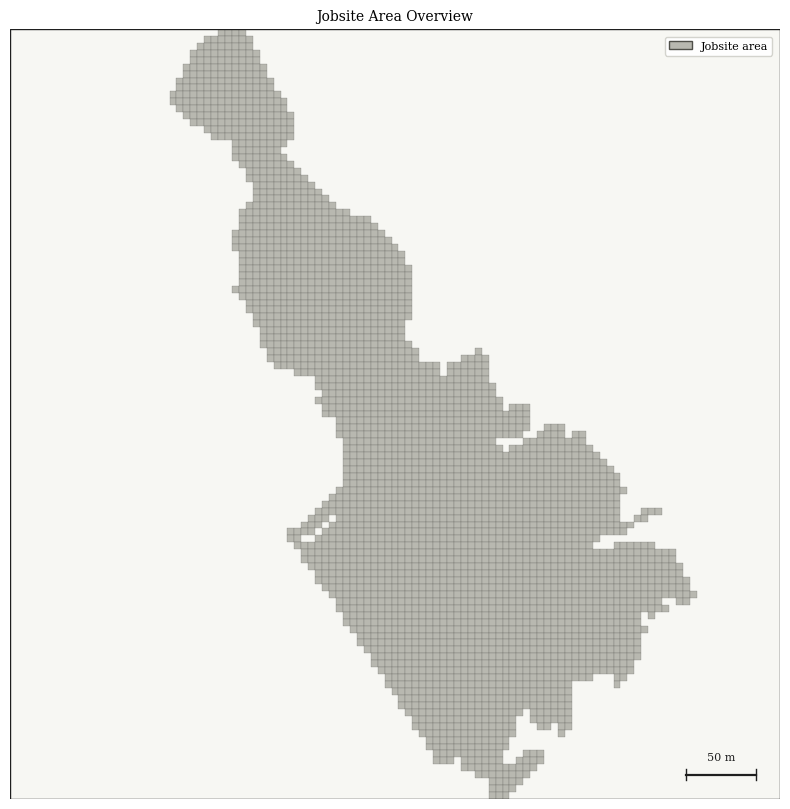

Saved figure: __RESULTS__/_plots/06-19-06-34/jobsite_map_overview.png


In [2]:
vis = VisualTool(show=True, size=(10, 10), save=True, dpi=100, save_dir="__RESULTS__/_plots", save_title=False)
map_data = MapLoader().load("gangjin/full")

installable_layer = layer_map(map_data, keep_values=[2])
road_layer = layer_map(map_data, keep_values=[3])
jobsite_layer = layer_map(map_data, keep_values=[2, 3])

vis.showMapOverview(map_data=map_data, title="Gangjin Construction Site Overview", filename="construction_map_overview")
vis.showMapOverview(
    map_data=installable_layer,
    title="Installable Area Overview",
    filename="installable_map_overview",
    zone_style="installable",
)
vis.showMapOverview(
    map_data=road_layer,
    title="Restricted Area Overview",
    filename="restricted_map_overview",
    zone_style="restricted",
)
vis.showMapOverview(
    map_data=jobsite_layer,
    title="Jobsite Area Overview",
    filename="jobsite_map_overview",
    zone_style="jobsite",
)

Outmost corner points: 8


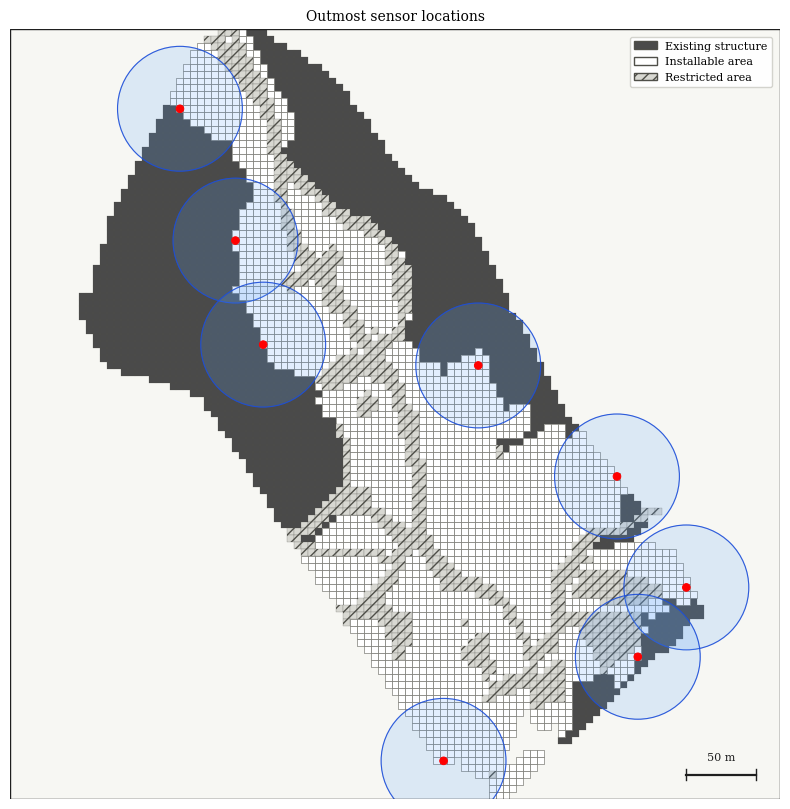

Saved figure: __RESULTS__/_plots/06-19-06-34/corner_sensors.png


In [3]:
COVERAGE = 45

corner_candidate = HarrisCorner(jobsite_layer).run(
    grid=jobsite_layer,
    installable_layer=installable_layer,
    blockSize=3,
    ksize=3,
    k=0.05,
    dilate_size=5,
    min_dist=9,
)

print("Outmost corner points:", len(corner_candidate))
vis.showMap_circle(
    map_data=map_data,
    sensor_positions=corner_candidate,
    title="Outmost sensor locations",
    radius=COVERAGE,
    cmap="gray",
    filename="corner_sensors",
)

In [4]:
drl = SensorDRL(
    installable_map=installable_layer,
    jobsite_map=jobsite_layer,
    coverage=COVERAGE,
    generations=1000,
    corner_positions=corner_candidate,
    min_sensors=0,
    max_sensors=140,
    candidate_stride=5,
    max_candidates=512,
    hidden_dim=128,
    replay_capacity=5000,
    batch_size=64,
    learning_rate=1e-3,
    gamma=0.95,
    target_sync_interval=100,
    warmup_steps=64,
    train_steps_per_action=1,
    backup_actions=64,
    fitness_kwargs={"target_coverage": 100.0},
)

optimized_result = drl.run(
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.985,
    heuristic_warmup_episodes=1,
    return_best_only=True,
)

[DRL 001/1000] inner=17 / coverage=99.55% / reward=1372.576 / loss=nan / epsilon=1.000 / time=0.076s
[DRL 002/1000] inner=23 / coverage=99.72% / reward=1245.194 / loss=nan / epsilon=0.985 / time=0.050s
[DRL 003/1000] inner=25 / coverage=99.41% / reward=1186.682 / loss=64.16575 / epsilon=0.970 / time=0.157s
[DRL 004/1000] inner=22 / coverage=99.10% / reward=1258.169 / loss=65.98497 / epsilon=0.956 / time=0.185s
[DRL 005/1000] inner=22 / coverage=99.17% / reward=1264.616 / loss=63.76969 / epsilon=0.941 / time=0.184s
[DRL 006/1000] inner=22 / coverage=99.21% / reward=1245.340 / loss=57.95562 / epsilon=0.927 / time=0.186s
[DRL 007/1000] inner=22 / coverage=99.24% / reward=1246.063 / loss=54.53938 / epsilon=0.913 / time=0.183s
[DRL 008/1000] inner=21 / coverage=99.41% / reward=1280.682 / loss=58.63636 / epsilon=0.900 / time=0.174s
[DRL 009/1000] inner=20 / coverage=98.90% / reward=1280.827 / loss=55.99475 / epsilon=0.886 / time=0.165s
[DRL 010/1000] inner=24 / coverage=99.38% / reward=1191.

In [5]:
print("[FINALIZE OUTPUT] drl.best_solution =", drl.best_solution)
print("[FINALIZE OUTPUT] len(drl.best_solution) =", len(drl.best_solution))
print("[FINALIZE OUTPUT] drl.corner_points =", drl.corner_points)
print("[FINALIZE OUTPUT] len(drl.corner_points) =", len(drl.corner_points))

[FINALIZE OUTPUT] drl.best_solution = [(50, 65), (65, 77), (48, 83), (39, 38), (64, 91), (42, 51), (37, 73), (62, 62), (29, 15), (49, 93), (36, 29), (23, 0), (77, 76), (65, 104), (55, 77), (39, 62), (38, 82)]
[FINALIZE OUTPUT] len(drl.best_solution) = 17
[FINALIZE OUTPUT] drl.corner_points = [(14, 11), (22, 30), (26, 45), (57, 48), (77, 64), (87, 80), (80, 90), (52, 105)]
[FINALIZE OUTPUT] len(drl.corner_points) = 8


Total number of Sensor: 25


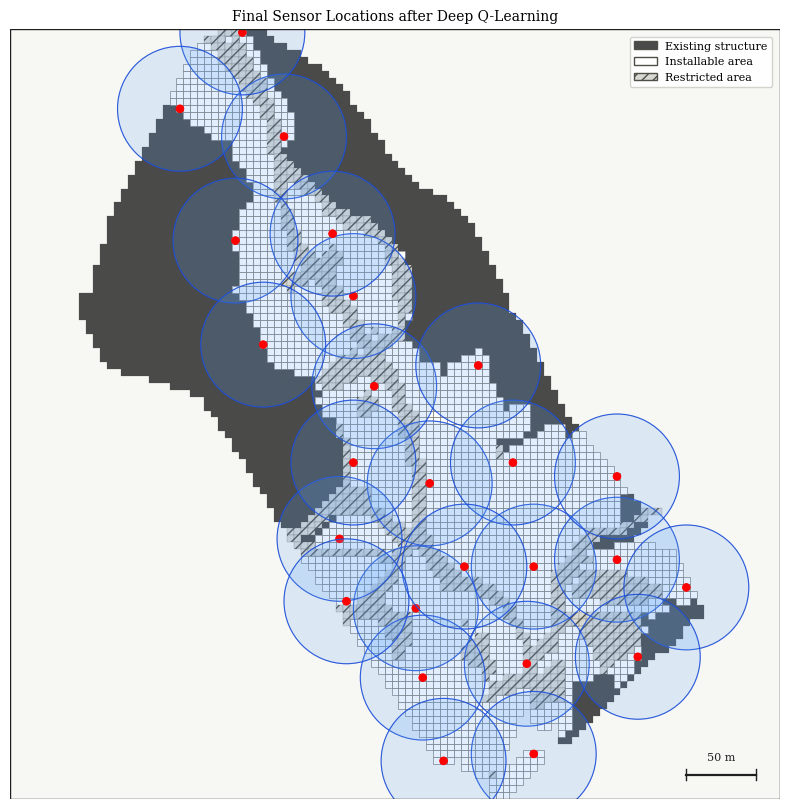

Saved figure: __RESULTS__/_plots/06-19-06-34/final_sensors_drl.png


In [ ]:
final_result = optimized_result + corner_candidate
print("Total number of Sensor:", len(final_result))
vis.showMap_circle(
    map_data=map_data,
    sensor_positions=final_result,
    title="Final Sensor Locations after Deep Q-Learning",
    radius=COVERAGE,
    cmap="gray",
    filename="[DRL]final_result"
)